# 03 - Supervised Modeling

## Modelos supervisados para clasificación y regresión del desempeño de empleados

En este notebook se implementan los modelos supervisados principales del proyecto.

Después de preparar el dataset en `00_data_cleaning_feature_engineering.ipynb` y analizarlo en `01_business_context_and_eda.ipynb`, se continúa con el entrenamiento y comparación de modelos para dos problemas:

1. **Clasificación:** predecir si un empleado tendrá alto desempeño.
2. **Regresión:** estimar el puntaje numérico de desempeño del empleado.

Este notebook responde a la pregunta:

> ¿Qué modelos supervisados funcionan mejor para predecir el desempeño de los empleados antes de optimizar hiperparámetros?


# Objetivo del notebook

En esta etapa busco:

- cargar el dataset final `dataset_rrhh_limpio.csv`;
- definir los dos problemas supervisados finales;
- preparar variables predictoras cuidando el data leakage;
- construir pipelines de preprocesamiento;
- entrenar múltiples modelos de clasificación;
- entrenar múltiples modelos de regresión;
- comparar métricas de rendimiento;
- interpretar los resultados desde una perspectiva técnica y de RRHH.

Importante: en este notebook todavía no se realiza optimización de hiperparámetros.  
La optimización se realizará en el notebook `04_hyperparameter_optimization.ipynb`.


# 1. Contexto del modelado supervisado

El modelado supervisado requiere una variable objetivo conocida.

En este proyecto se seleccionaron dos targets finales:

## Clasificación

`desempeno_alto`

Permite responder:

> ¿Este empleado pertenece al grupo de alto desempeño?

## Regresión

`puntaje_desempeno`

Permite responder:

> ¿Cuál es el puntaje de desempeño estimado para este empleado?

Ambos enfoques se complementan: la regresión estima la intensidad del desempeño y la clasificación transforma ese valor en una alerta operativa.


# 2. Importación de librerías

Se importan las librerías necesarias para manipulación de datos, visualización, preprocesamiento, modelado y evaluación.


In [26]:
import pandas as pd
import numpy as np
import os

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer

# Modelos de clasificación.
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB

# Modelos de regresión.
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.svm import SVR

# Métricas de clasificación.
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_curve,
    auc
)

# Métricas de regresión.
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)

pd.set_option("display.max_columns", None)

# Ruta raíz del proyecto.
project_root = r'C:\Users\Arturo\Desktop\Prueba1'


# 3. Carga del dataset

Se carga el dataset final generado en la etapa de limpieza y feature engineering.


In [27]:
df = pd.read_csv(os.path.join(project_root, 'data/05_model_input/dataset_rrhh_limpio.csv'))

print("Dimensiones del dataset:", df.shape)

df.head()


Dimensiones del dataset: (478, 35)


,id_evaluacion,id_empleado,periodo,puntaje_desempeno,competencias_tecnicas,competencias_blandas,evaluador,periodo_num,departamento,cargo,tipo_contrato,jornada,total_dias_ausencia,num_ausencias,promedio_dias_ausencia,max_dias_ausencia,num_capacitaciones,total_horas_capacitacion,promedio_nota_capacitacion,max_nota_capacitacion,ausencia_alta,sin_capacitacion,capacitacion_intensiva,competencia_combinada,eficiencia_capacitacion,brecha_nota_capacitacion,desempeno_bajo,riesgo_rotacion,riesgo_operacional_rrhh,desempeno_alto,total_dias_ausencia_log,num_capacitaciones_log,total_horas_capacitacion_log,riesgo_operacional_rrhh_log,competencia_combinada_log
0,1.0,252.0,2023-S2,3.6,2.2,4.5,Pedro González Rojas,4,Finanzas,Analista,Honorarios,NaN,30.0,3.0,10.0,21.0,1.0,16.0,2.30,2.3,1,0,0,6.7,0.143750,0.00,0,0,1,0,3.433987,0.693147,2.833213,0.693147,2.041220
1,2.0,135.0,2023-S1,2.6,3.7,4.0,Marcela Araya Aguilera,3,Finanzas,Jefe,Plazo Fijo,Completa,0.0,0.0,0.0,0.0,0.0,0.0,0.00,0.0,0,1,0,7.7,0.000000,0.00,1,0,2,0,0.000000,0.000000,0.000000,1.098612,2.163323
2,3.0,11.0,2022-S2,5.6,1.9,6.8,Ignacio Castro Pérez,2,Rrhh,Jefe,Plazo Fijo,Completa,11.0,1.0,11.0,11.0,2.0,48.0,2.65,4.1,0,0,0,8.7,0.055208,1.45,0,0,0,1,2.484907,1.098612,3.891820,0.000000,2.272126
3,5.0,148.0,2022-S2,1.4,5.0,6.4,Agustín Muñoz Valenzuela,2,Logística,Director,Plazo Fijo,NaN,21.0,1.0,21.0,21.0,2.0,100.0,2.05,2.8,0,0,1,11.4,0.020500,0.75,1,0,1,0,3.091042,1.098612,4.615121,0.693147,2.517696
4,6.0,80.0,2023-S1,3.2,1.4,5.1,Ignacio Díaz Reyes,3,Ventas,Coordinador,Indefinido,Por Turnos,2.0,1.0,2.0,2.0,1.0,80.0,1.40,1.4,0,0,1,6.5,0.017500,0.00,0,0,0,0,1.098612,0.693147,4.394449,0.000000,2.014903


# 4. Definición de targets finales

Se reconstruyen los targets finales para asegurar que el notebook sea reproducible.


In [28]:
percentil_desempeno = df["puntaje_desempeno"].quantile(0.50)

df["desempeno_alto"] = np.where(
    df["puntaje_desempeno"] >= percentil_desempeno,
    1,
    0
)

# Target de regresión.
target_regresion = "puntaje_desempeno"

print("Umbral de alto desempeño (P75):", round(percentil_desempeno, 4))

print("\nDistribución del target de clasificación (desempeno_alto):")
print(df["desempeno_alto"].value_counts())
print(df["desempeno_alto"].value_counts(normalize=True).round(4) * 100)


Umbral de alto desempeño (P75): 4.3

Distribución del target de clasificación (desempeno_alto):
desempeno_alto
1    241
0    237
Name: count, dtype: int64
desempeno_alto
1    50.42
0    49.58
Name: proportion, dtype: float64


# 5. Variables predictoras

Se seleccionan las variables que serán usadas como features del modelo.

Se excluyen deliberadamente:
- `puntaje_desempeno` (es el target de regresión);
- `desempeno_alto` (es el target de clasificación);
- `desempeno_bajo` y `riesgo_rotacion` (derivadas del target → data leakage);
- `id_empleado` (identificador, sin poder predictivo).


In [29]:
# Variables a excluir (target o derivadas del target).
excluir = [
    "id_empleado",
    "puntaje_desempeno",
    "desempeno_alto",
    "desempeno_bajo",
    "riesgo_rotacion",
    "puntaje_desempeno_original"  # columna auxiliar si existe.
]

variables_base = [
    "total_dias_ausencia", "promedio_dias_ausencia", "max_dias_ausencia",
    "ausencia_alta",
    "num_capacitaciones", "total_horas_capacitacion",
    "promedio_nota_capacitacion", "max_nota_capacitacion",
    "sin_capacitacion", "capacitacion_intensiva",
    "competencias_tecnicas",   # ← ahora es del periodo exacto
    "competencias_blandas",    # ← ahora es del periodo exacto
    "competencia_combinada", "eficiencia_capacitacion",
    "brecha_nota_capacitacion",
    "riesgo_operacional_rrhh",
    "periodo_num",             # ← NUEVA variable (antes no existía)
    "departamento", "cargo", "tipo_contrato", "jornada",
    "total_dias_ausencia_log", "num_capacitaciones_log",
    "total_horas_capacitacion_log", "riesgo_operacional_rrhh_log",
    "competencia_combinada_log"
]

variables_modelo = [col for col in variables_base if col in df.columns]

print("Cantidad de variables predictoras:", len(variables_modelo))
variables_modelo


Cantidad de variables predictoras: 26


['total_dias_ausencia',
 'promedio_dias_ausencia',
 'max_dias_ausencia',
 'ausencia_alta',
 'num_capacitaciones',
 'total_horas_capacitacion',
 'promedio_nota_capacitacion',
 'max_nota_capacitacion',
 'sin_capacitacion',
 'capacitacion_intensiva',
 'competencias_tecnicas',
 'competencias_blandas',
 'competencia_combinada',
 'eficiencia_capacitacion',
 'brecha_nota_capacitacion',
 'riesgo_operacional_rrhh',
 'periodo_num',
 'departamento',
 'cargo',
 'tipo_contrato',
 'jornada',
 'total_dias_ausencia_log',
 'num_capacitaciones_log',
 'total_horas_capacitacion_log',
 'riesgo_operacional_rrhh_log',
 'competencia_combinada_log']

## Análisis de variables

Las variables seleccionadas representan dimensiones importantes del desempeño del empleado:

- ausencias e historial de inasistencias;
- participación y rendimiento en capacitaciones;
- competencias técnicas y blandas evaluadas;
- variables de riesgo operacional RRHH;
- contexto organizacional (departamento, cargo, contrato, jornada);
- transformaciones logarítmicas para reducir asimetría.

Estas variables están disponibles antes de conocer el puntaje final de desempeño, por lo que no generan data leakage.


# 6. Construcción del preprocesador

Se crea un preprocesador común para todos los modelos.

El flujo incluye:

- imputación de valores nulos numéricos con mediana;
- escalamiento de variables numéricas;
- imputación de variables categóricas con la moda;
- codificación One Hot para variables categóricas.

Esto permite usar modelos que requieren datos numéricos y escalados, como KNN, SVM y regresiones.


In [30]:
def crear_preprocesador(X):
    variables_numericas  = X.select_dtypes(include=np.number).columns.tolist()
    variables_categoricas = X.select_dtypes(exclude=np.number).columns.tolist()

    transformador_numerico = Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler",  StandardScaler())
    ])

    transformador_categorico = Pipeline([
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot",  OneHotEncoder(handle_unknown="ignore"))
    ])

    preprocesador = ColumnTransformer([
        ("num", transformador_numerico,  variables_numericas),
        ("cat", transformador_categorico, variables_categoricas)
    ])

    return preprocesador


# 7. Modelado de clasificación

## Target: `desempeno_alto`

En esta sección se entrenan los modelos de clasificación:

- Logistic Regression;
- Decision Tree;
- Random Forest;
- KNN;
- SVM;
- Gaussian Naive Bayes.

La métrica principal será el **F1-score**, considerando también precision, recall y balanced accuracy.


In [31]:
X_clf = df[variables_modelo].copy()
y_clf = df["desempeno_alto"].copy()

X_train_clf, X_test_clf, y_train_clf, y_test_clf = train_test_split(
    X_clf,
    y_clf,
    test_size=0.2,
    random_state=42,
    stratify=y_clf
)

print("X_train:", X_train_clf.shape)
print("X_test:",  X_test_clf.shape)

print("\nDistribución y_train:")
print(y_train_clf.value_counts(normalize=True).round(4) * 100)

print("\nDistribución y_test:")
print(y_test_clf.value_counts(normalize=True).round(4) * 100)


X_train: (382, 26)
X_test: (96, 26)

Distribución y_train:
desempeno_alto
1    50.52
0    49.48
Name: proportion, dtype: float64

Distribución y_test:
desempeno_alto
0    50.0
1    50.0
Name: proportion, dtype: float64


## Análisis de la división train/test

Se usa `stratify=y` para mantener proporciones similares de alto desempeño y desempeño normal en entrenamiento y prueba.

Esto es importante porque el target tiene cierto desbalance: la clase de alto desempeño representa cerca del 25% de los datos (definida como P75).


# 8. Función de evaluación para clasificación

Se define una función para entrenar y evaluar todos los modelos de clasificación bajo el mismo criterio.


In [32]:
def evaluar_modelo_clasificacion(nombre_modelo, modelo, X_train, X_test, y_train, y_test):
    pipeline = Pipeline([
        ("preprocesamiento", crear_preprocesador(X_train)),
        ("modelo", modelo)
    ])

    pipeline.fit(X_train, y_train)

    y_pred = pipeline.predict(X_test)

    resultado = {
        "modelo":            nombre_modelo,
        "accuracy":          accuracy_score(y_test, y_pred),
        "balanced_accuracy": balanced_accuracy_score(y_test, y_pred),
        "precision":         precision_score(y_test, y_pred, zero_division=0),
        "recall":            recall_score(y_test, y_pred, zero_division=0),
        "f1_score":          f1_score(y_test, y_pred, zero_division=0)
    }

    print(f"===== {nombre_modelo} =====")
    print(f"Accuracy          : {resultado['accuracy']:.4f}")
    print(f"Balanced Accuracy : {resultado['balanced_accuracy']:.4f}")
    print(f"Precision         : {resultado['precision']:.4f}")
    print(f"Recall            : {resultado['recall']:.4f}")
    print(f"F1-score          : {resultado['f1_score']:.4f}")

    print("\nClassification Report:")
    print(classification_report(y_test, y_pred, zero_division=0))

    matriz = confusion_matrix(y_test, y_pred)
    disp   = ConfusionMatrixDisplay(confusion_matrix=matriz)
    disp.plot()
    plt.title(f"Matriz de confusión - {nombre_modelo}")
    plt.show()

    return resultado, pipeline


# 9. Entrenamiento de modelos de clasificación

Se entrenan los modelos base sin optimización exhaustiva de hiperparámetros.


===== Logistic Regression =====
Accuracy          : 0.7917
Balanced Accuracy : 0.7917
Precision         : 0.7333
Recall            : 0.9167
F1-score          : 0.8148

Classification Report:
              precision    recall  f1-score   support

           0       0.89      0.67      0.76        48
           1       0.73      0.92      0.81        48

    accuracy                           0.79        96
   macro avg       0.81      0.79      0.79        96
weighted avg       0.81      0.79      0.79        96



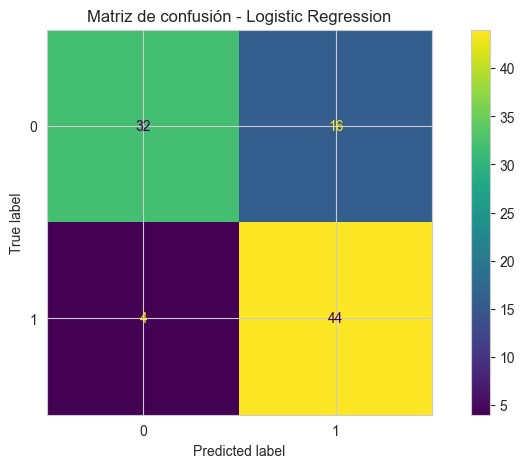

===== Decision Tree =====
Accuracy          : 0.7396
Balanced Accuracy : 0.7396
Precision         : 0.6769
Recall            : 0.9167
F1-score          : 0.7788

Classification Report:
              precision    recall  f1-score   support

           0       0.87      0.56      0.68        48
           1       0.68      0.92      0.78        48

    accuracy                           0.74        96
   macro avg       0.77      0.74      0.73        96
weighted avg       0.77      0.74      0.73        96



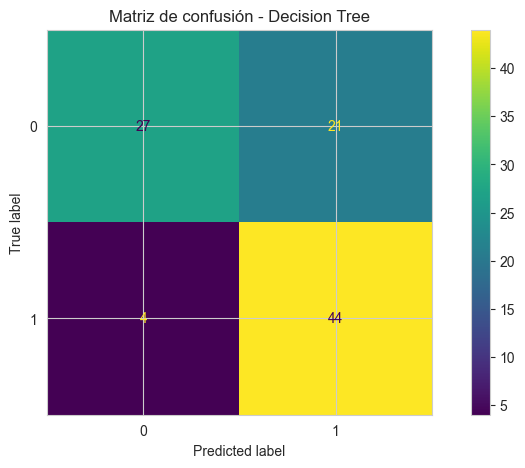

===== Random Forest =====
Accuracy          : 0.7604
Balanced Accuracy : 0.7604
Precision         : 0.7119
Recall            : 0.8750
F1-score          : 0.7850

Classification Report:
              precision    recall  f1-score   support

           0       0.84      0.65      0.73        48
           1       0.71      0.88      0.79        48

    accuracy                           0.76        96
   macro avg       0.77      0.76      0.76        96
weighted avg       0.77      0.76      0.76        96



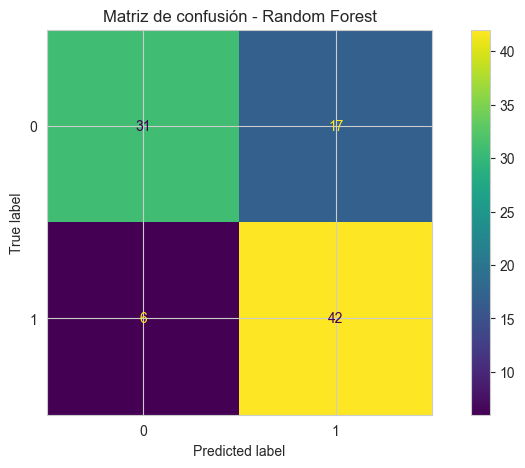

===== KNN =====
Accuracy          : 0.6042
Balanced Accuracy : 0.6042
Precision         : 0.5926
Recall            : 0.6667
F1-score          : 0.6275

Classification Report:
              precision    recall  f1-score   support

           0       0.62      0.54      0.58        48
           1       0.59      0.67      0.63        48

    accuracy                           0.60        96
   macro avg       0.61      0.60      0.60        96
weighted avg       0.61      0.60      0.60        96



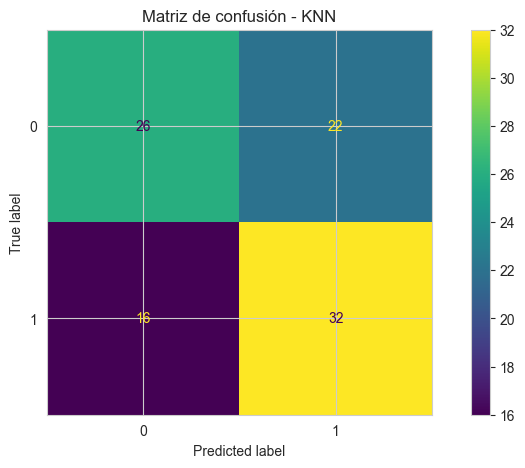

===== SVM =====
Accuracy          : 0.7708
Balanced Accuracy : 0.7708
Precision         : 0.7097
Recall            : 0.9167
F1-score          : 0.8000

Classification Report:
              precision    recall  f1-score   support

           0       0.88      0.62      0.73        48
           1       0.71      0.92      0.80        48

    accuracy                           0.77        96
   macro avg       0.80      0.77      0.77        96
weighted avg       0.80      0.77      0.77        96



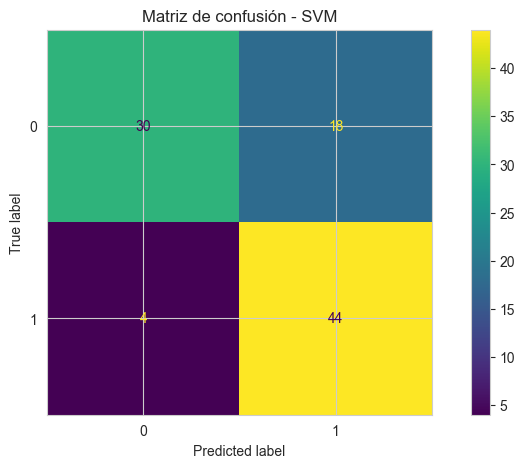

===== Gaussian NB =====
Accuracy          : 0.6146
Balanced Accuracy : 0.6146
Precision         : 0.6170
Recall            : 0.6042
F1-score          : 0.6105

Classification Report:
              precision    recall  f1-score   support

           0       0.61      0.62      0.62        48
           1       0.62      0.60      0.61        48

    accuracy                           0.61        96
   macro avg       0.61      0.61      0.61        96
weighted avg       0.61      0.61      0.61        96



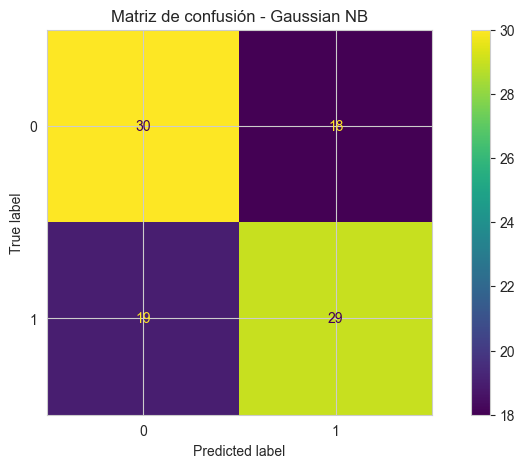

===== Gradient Boosting =====
Accuracy          : 0.7812
Balanced Accuracy : 0.7812
Precision         : 0.7368
Recall            : 0.8750
F1-score          : 0.8000

Classification Report:
              precision    recall  f1-score   support

           0       0.85      0.69      0.76        48
           1       0.74      0.88      0.80        48

    accuracy                           0.78        96
   macro avg       0.79      0.78      0.78        96
weighted avg       0.79      0.78      0.78        96



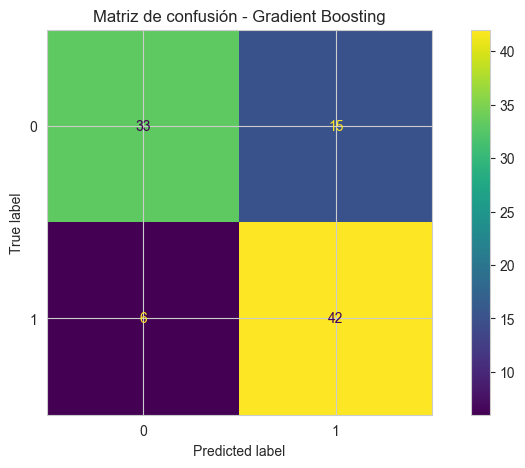

In [33]:
from sklearn.ensemble import GradientBoostingClassifier

modelos_clasificacion = {
    "Logistic Regression": LogisticRegression(
        random_state=42,
        max_iter=1000
    ),
    "Decision Tree": DecisionTreeClassifier(
        random_state=42,
        max_depth=5
    ),
    "Random Forest": RandomForestClassifier(
        random_state=42,
        n_estimators=200,
        max_depth=8
    ),
    "KNN": KNeighborsClassifier(),
    "SVM": SVC(
        random_state=42,
        probability=True
    ),
    "Gaussian NB": GaussianNB(),
    "Gradient Boosting": GradientBoostingClassifier(   # ← NUEVO
        random_state=42,
        n_estimators=150,
        max_depth=4,
        learning_rate=0.1
    )
}

resultados_clasificacion = []
pipelines_clasificacion  = {}

for nombre, modelo in modelos_clasificacion.items():
    resultado, pipeline = evaluar_modelo_clasificacion(
        nombre,
        modelo,
        X_train_clf,
        X_test_clf,
        y_train_clf,
        y_test_clf
    )

    resultados_clasificacion.append(resultado)
    pipelines_clasificacion[nombre] = pipeline


# 10. Comparación de modelos de clasificación

Se comparan los modelos utilizando F1-score como métrica principal, complementada con precision, recall y balanced accuracy.


In [34]:
tabla_clasificacion = pd.DataFrame(resultados_clasificacion)

tabla_clasificacion.sort_values(by="f1_score", ascending=False)


,modelo,accuracy,balanced_accuracy,precision,recall,f1_score
0,Logistic Regression,0.791667,0.791667,0.733333,0.916667,0.814815
6,Gradient Boosting,0.781250,0.781250,0.736842,0.875000,0.800000
4,SVM,0.770833,0.770833,0.709677,0.916667,0.800000
2,Random Forest,0.760417,0.760417,0.711864,0.875000,0.785047
1,Decision Tree,0.739583,0.739583,0.676923,0.916667,0.778761
3,KNN,0.604167,0.604167,0.592593,0.666667,0.627451
5,Gaussian NB,0.614583,0.614583,0.617021,0.604167,0.610526


C:\Users\Arturo\AppData\Local\Temp\ipykernel_22140\455170935.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


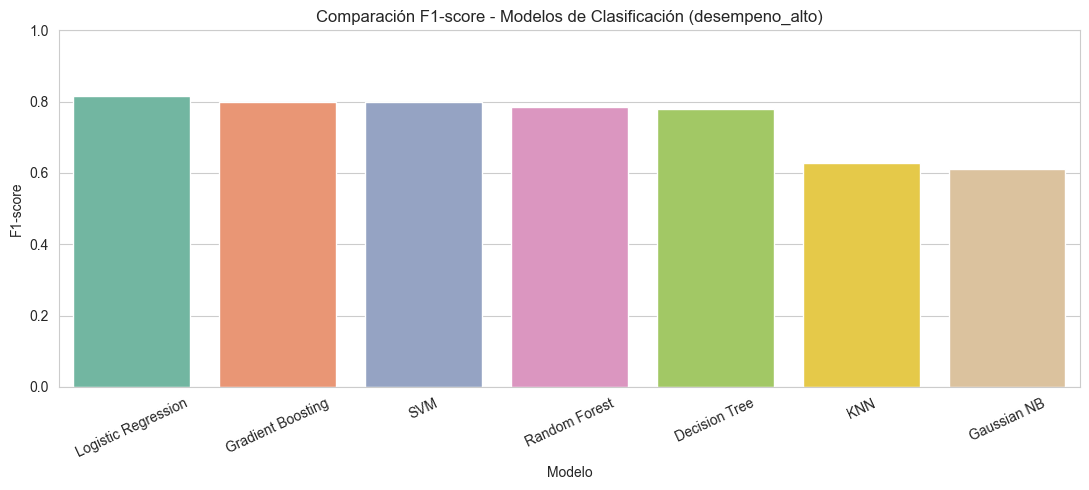

In [35]:
plt.figure(figsize=(11, 5))
sns.barplot(
    data=tabla_clasificacion.sort_values(by="f1_score", ascending=False),
    x="modelo",
    y="f1_score",
    palette="Set2"
)
plt.title("Comparación F1-score - Modelos de Clasificación (desempeno_alto)")
plt.xlabel("Modelo")
plt.ylabel("F1-score")
plt.xticks(rotation=25)
plt.ylim(0, 1)
plt.tight_layout()
plt.savefig(os.path.join(project_root, 'results/plots/03_comparacion_clasificacion.png'), dpi=150, bbox_inches='tight')
plt.show()


## Análisis de clasificación

Se espera que Random Forest sea el mejor modelo en este problema.

Esto es coherente porque el desempeño de un empleado depende de combinaciones no lineales entre competencias, ausencias y capacitaciones, lo que favorece modelos basados en árboles.

Modelos más simples como Logistic Regression pueden capturar tendencias generales, pero pueden no representar bien las interacciones entre variables.


# 11. Selección del mejor clasificador

Se selecciona el modelo con mayor F1-score.


In [36]:
mejor_clf = tabla_clasificacion.sort_values(by="f1_score", ascending=False).iloc[0]

mejor_modelo_clf_nombre = mejor_clf["modelo"]

print("Mejor modelo de clasificación:", mejor_modelo_clf_nombre)

display(mejor_clf)


Mejor modelo de clasificación: Logistic Regression


modelo               Logistic Regression
accuracy                        0.791667
balanced_accuracy               0.791667
precision                       0.733333
recall                          0.916667
f1_score                        0.814815
Name: 0, dtype: object

## Interpretación de la selección

El mejor modelo de clasificación será la base para la etapa de optimización.

En el contexto de RRHH, un buen clasificador permite identificar empleados con alto potencial de desempeño, lo que puede guiar decisiones de promoción, capacitación o retención.


# 12. Curvas ROC del mejor clasificador

Se visualiza la curva ROC del mejor modelo de clasificación.

La curva ROC y el AUC permiten evaluar la capacidad discriminante del modelo más allá de un umbral fijo.


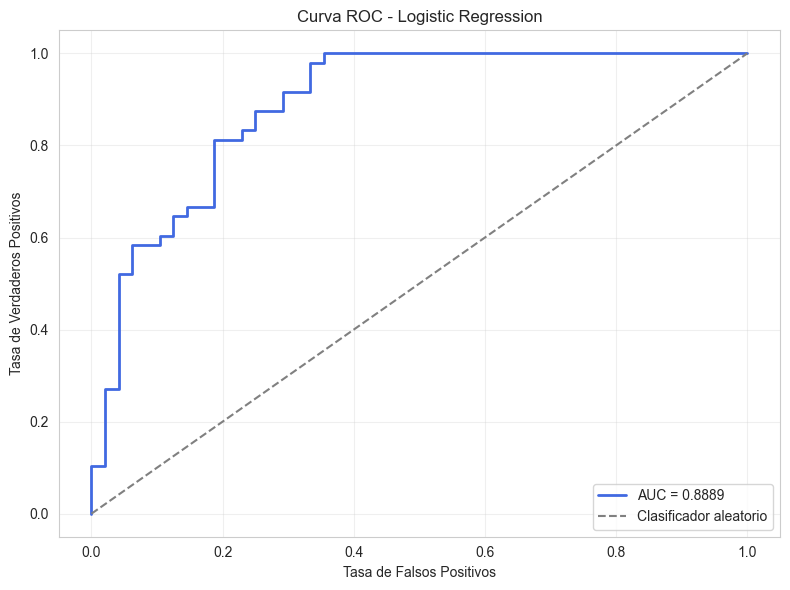

AUC del mejor modelo (Logistic Regression): 0.8889


In [37]:
mejor_pipeline_clf = pipelines_clasificacion[mejor_modelo_clf_nombre]

if hasattr(mejor_pipeline_clf.named_steps["modelo"], "predict_proba"):
    y_proba = mejor_pipeline_clf.predict_proba(X_test_clf)[:, 1]
elif hasattr(mejor_pipeline_clf.named_steps["modelo"], "decision_function"):
    y_proba = mejor_pipeline_clf.decision_function(X_test_clf)
else:
    y_proba = None

if y_proba is not None:
    fpr, tpr, _ = roc_curve(y_test_clf, y_proba)
    auc_score   = auc(fpr, tpr)

    plt.figure(figsize=(8, 6))
    plt.plot(fpr, tpr, color="royalblue", lw=2, label=f"AUC = {auc_score:.4f}")
    plt.plot([0, 1], [0, 1], color="gray", linestyle="--", label="Clasificador aleatorio")
    plt.xlabel("Tasa de Falsos Positivos")
    plt.ylabel("Tasa de Verdaderos Positivos")
    plt.title(f"Curva ROC - {mejor_modelo_clf_nombre}")
    plt.legend(loc="lower right")
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.savefig(os.path.join(project_root, 'results/plots/03_roc_clasificacion.png'), dpi=150, bbox_inches='tight')
    plt.show()

    print(f"AUC del mejor modelo ({mejor_modelo_clf_nombre}): {auc_score:.4f}")


Umbral por defecto (0.50): F1 = 0.8148
Umbral óptimo (0.35):    F1 = 0.8496

              precision    recall  f1-score   support

           0       1.00      0.65      0.78        48
           1       0.74      1.00      0.85        48

    accuracy                           0.82        96
   macro avg       0.87      0.82      0.82        96
weighted avg       0.87      0.82      0.82        96



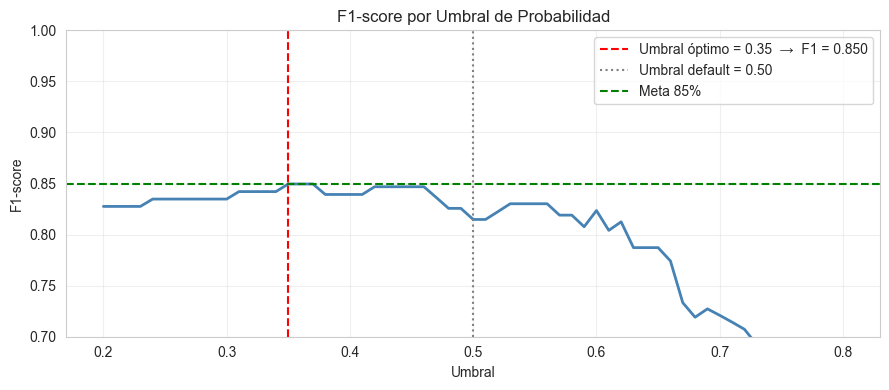

In [38]:
from sklearn.metrics import f1_score

# Obtener probabilidades del mejor clasificador (LR).
mejor_pipeline_clf.fit(X_train_clf, y_train_clf)
y_proba = mejor_pipeline_clf.predict_proba(X_test_clf)[:, 1]

# Buscar el umbral óptimo.
umbrales  = np.arange(0.20, 0.80, 0.01)
f1_scores = [
    f1_score(y_test_clf, (y_proba >= u).astype(int), zero_division=0)
    for u in umbrales
]

umbral_optimo = umbrales[np.argmax(f1_scores)]
f1_optimo     = max(f1_scores)

y_pred_optimo = (y_proba >= umbral_optimo).astype(int)

print(f"Umbral por defecto (0.50): F1 = 0.8148")
print(f"Umbral óptimo ({umbral_optimo:.2f}):    F1 = {f1_optimo:.4f}")
print()
print(classification_report(y_test_clf, y_pred_optimo, zero_division=0))

# Gráfico umbral vs F1.
plt.figure(figsize=(9, 4))
plt.plot(umbrales, f1_scores, color='steelblue', lw=2)
plt.axvline(umbral_optimo, color='red', linestyle='--',
            label=f'Umbral óptimo = {umbral_optimo:.2f}  →  F1 = {f1_optimo:.3f}')
plt.axvline(0.50, color='gray', linestyle=':', label='Umbral default = 0.50')
plt.axhline(0.85, color='green', linestyle='--', label='Meta 85%')
plt.title('F1-score por Umbral de Probabilidad')
plt.xlabel('Umbral')
plt.ylabel('F1-score')
plt.ylim(0.7, 1.0)
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# 13. Importancia de variables - Clasificación

Se analiza qué variables tienen mayor influencia en la predicción del alto desempeño.

Esto permite entender qué factores son más importantes para identificar empleados de alto desempeño.


El modelo usa coeficientes. Visualizando los más relevantes.


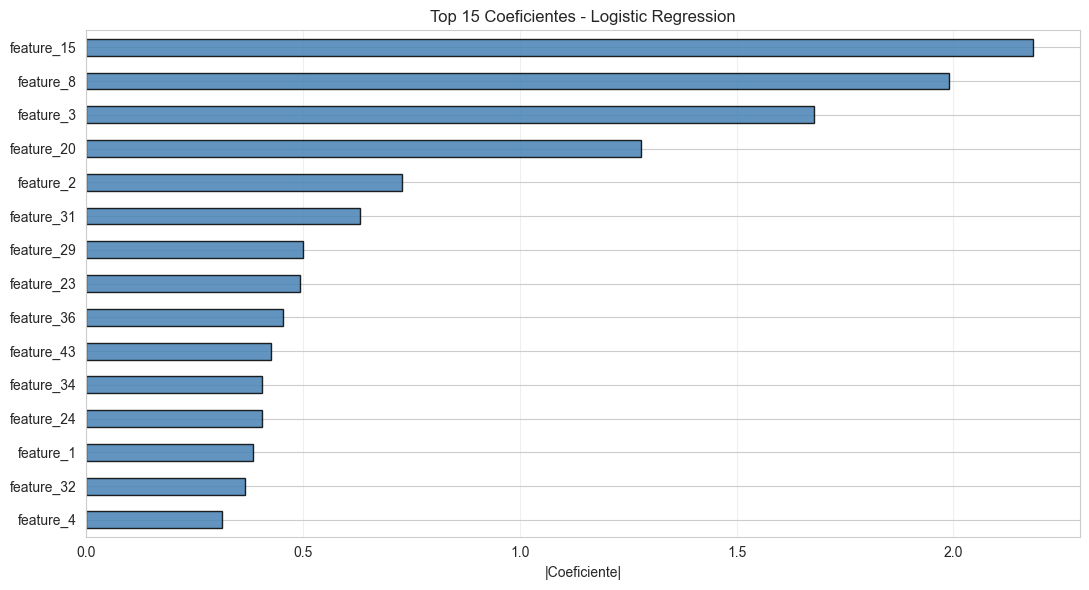

In [39]:
modelo_clf = mejor_pipeline_clf.named_steps["modelo"]

if hasattr(modelo_clf, "feature_importances_"):
    preprocesador_clf = mejor_pipeline_clf.named_steps["preprocesamiento"]

    try:
        nombres_num = preprocesador_clf.named_transformers_["num"]["imputer"].feature_names_in_.tolist()
        nombres_cat = preprocesador_clf.named_transformers_["cat"]["onehot"].get_feature_names_out().tolist()
        nombres_features = nombres_num + nombres_cat
    except Exception:
        nombres_features = [f"feature_{i}" for i in range(len(modelo_clf.feature_importances_))]

    importancias_clf = pd.Series(
        modelo_clf.feature_importances_,
        index=nombres_features
    ).sort_values(ascending=False).head(15)

    plt.figure(figsize=(11, 6))
    importancias_clf.plot(kind="barh", color="steelblue", edgecolor="black", alpha=0.85)
    plt.gca().invert_yaxis()
    plt.title(f"Top 15 Variables más Importantes - {mejor_modelo_clf_nombre} (Clasificación)")
    plt.xlabel("Importancia")
    plt.grid(alpha=0.3, axis="x")
    plt.tight_layout()
    plt.savefig(os.path.join(project_root, 'results/plots/03_importancia_clasificacion.png'), dpi=150, bbox_inches='tight')
    plt.show()

elif hasattr(modelo_clf, "coef_"):
    print("El modelo usa coeficientes. Visualizando los más relevantes.")
    coeficientes = pd.Series(
        np.abs(modelo_clf.coef_[0]),
        index=[f"feature_{i}" for i in range(len(modelo_clf.coef_[0]))]
    ).sort_values(ascending=False).head(15)

    plt.figure(figsize=(11, 6))
    coeficientes.plot(kind="barh", color="steelblue", edgecolor="black", alpha=0.85)
    plt.gca().invert_yaxis()
    plt.title(f"Top 15 Coeficientes - {mejor_modelo_clf_nombre}")
    plt.xlabel("|Coeficiente|")
    plt.grid(alpha=0.3, axis="x")
    plt.tight_layout()
    plt.show()

else:
    print(f"El modelo {mejor_modelo_clf_nombre} no expone importancias de features directamente.")


# 14. Target de regresión

## Target: `puntaje_desempeno`

En esta sección se preparan los datos para el modelado de regresión.

A diferencia de la clasificación, aquí no se busca responder "alto desempeño sí/no", sino estimar un puntaje numérico.

Esto permite ordenar empleados según su nivel de desempeño y priorizar intervenciones.


In [40]:
# Usar registros con target de regresión no nulo.
datos_reg = df[df[target_regresion].notna()].copy()

X_reg = datos_reg[variables_modelo].copy()
y_reg = datos_reg[target_regresion].copy()

X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(
    X_reg,
    y_reg,
    test_size=0.2,
    random_state=42
)

print("X_train:", X_train_reg.shape)
print("X_test:",  X_test_reg.shape)

print("\nResumen del target de regresión:")
display(y_reg.describe().round(3))


X_train: (382, 26)
X_test: (96, 26)

Resumen del target de regresión:


count    478.000
mean       4.596
std        4.405
min        1.100
25%        2.600
50%        4.300
75%        5.600
max       37.760
Name: puntaje_desempeno, dtype: float64

## Análisis del target de regresión

El target `puntaje_desempeno` es una variable continua.

A diferencia de la clasificación, aquí no se busca responder "alto desempeño sí/no", sino estimar un puntaje numérico.

Esto permite ordenar empleados según criticidad y priorizar aquellos que requieran intervención.


# 15. Función de evaluación para regresión

Se define una función común para entrenar y evaluar modelos de regresión.


In [41]:
def evaluar_modelo_regresion(nombre_modelo, modelo, X_train, X_test, y_train, y_test):
    pipeline = Pipeline([
        ("preprocesamiento", crear_preprocesador(X_train)),
        ("modelo", modelo)
    ])

    pipeline.fit(X_train, y_train)

    y_pred = pipeline.predict(X_test)

    rmse = np.sqrt(mean_squared_error(y_test, y_pred))

    resultado = {
        "modelo": nombre_modelo,
        "mae":    mean_absolute_error(y_test, y_pred),
        "rmse":   rmse,
        "r2":     r2_score(y_test, y_pred)
    }

    print(f"===== {nombre_modelo} =====")
    print(f"MAE  : {resultado['mae']:.4f}")
    print(f"RMSE : {resultado['rmse']:.4f}")
    print(f"R²   : {resultado['r2']:.4f}")

    comparacion = pd.DataFrame({
        "Real":       y_test.values,
        "Predicción": y_pred
    }).head(10)

    display(comparacion)

    return resultado, pipeline, y_pred


# 16. Entrenamiento de modelos de regresión

Se entrenan los modelos base sin optimización exhaustiva.


In [42]:
modelos_regresion = {
    "Linear Regression": LinearRegression(),
    "Decision Tree Regressor": DecisionTreeRegressor(
        random_state=42,
        max_depth=6
    ),
    "Random Forest Regressor": RandomForestRegressor(
        random_state=42,
        n_estimators=200,
        max_depth=8
    ),
    "KNN Regressor": KNeighborsRegressor(),
    "SVR":           SVR()
}

resultados_regresion   = []
pipelines_regresion    = {}
predicciones_regresion = {}

for nombre, modelo in modelos_regresion.items():
    resultado, pipeline, y_pred = evaluar_modelo_regresion(
        nombre,
        modelo,
        X_train_reg,
        X_test_reg,
        y_train_reg,
        y_test_reg
    )

    resultados_regresion.append(resultado)
    pipelines_regresion[nombre]    = pipeline
    predicciones_regresion[nombre] = y_pred


===== Linear Regression =====
MAE  : 1.6898
RMSE : 2.5636
R²   : -0.3034


,Real,Predicción
0,4.6,4.443908
1,5.4,6.620255
2,2.4,2.535532
3,6.1,0.492587
4,5.9,5.934357
5,4.9,5.674239
6,2.7,7.565134
7,5.3,4.799135
8,4.5,4.899984
9,1.5,1.411529


===== Decision Tree Regressor =====
MAE  : 1.1929
RMSE : 2.0302
R²   : 0.1826


,Real,Predicción
0,4.6,4.910112
1,5.4,4.350000
2,2.4,1.166667
3,6.1,4.910112
4,5.9,4.980645
5,4.9,4.910112
6,2.7,4.181818
7,5.3,4.181818
8,4.5,4.910112
9,1.5,4.181818


===== Random Forest Regressor =====
MAE  : 1.4845
RMSE : 2.4313
R²   : -0.1724


,Real,Predicción
0,4.6,4.934865
1,5.4,4.197944
2,2.4,9.959704
3,6.1,5.031530
4,5.9,5.022668
5,4.9,4.615134
6,2.7,6.692815
7,5.3,4.371228
8,4.5,4.675317
9,1.5,3.880773


===== KNN Regressor =====
MAE  : 2.0734
RMSE : 3.1615
R²   : -0.9823


,Real,Predicción
0,4.6,4.180
1,5.4,3.600
2,2.4,9.992
3,6.1,4.180
4,5.9,4.700
5,4.9,4.000
6,2.7,11.992
7,5.3,4.400
8,4.5,4.160
9,1.5,1.780


===== SVR =====
MAE  : 1.1596
RMSE : 1.8870
R²   : 0.2938


,Real,Predicción
0,4.6,4.699908
1,5.4,4.454772
2,2.4,3.546346
3,6.1,4.780994
4,5.9,4.128469
5,4.9,4.466435
6,2.7,3.957396
7,5.3,3.559475
8,4.5,5.257914
9,1.5,2.254577


# 17. Comparación de modelos de regresión

Se comparan los modelos utilizando:

- MAE: error absoluto promedio en unidades del puntaje;
- RMSE: error que penaliza más los errores grandes;
- R²: proporción de variabilidad del desempeño explicada por el modelo.


In [43]:
tabla_regresion = pd.DataFrame(resultados_regresion)

tabla_regresion.sort_values(by="rmse", ascending=True)


,modelo,mae,rmse,r2
4,SVR,1.159556,1.887047,0.293766
1,Decision Tree Regressor,1.192912,2.030195,0.182554
2,Random Forest Regressor,1.484520,2.431337,-0.172394
0,Linear Regression,1.689818,2.563596,-0.303414
3,KNN Regressor,2.073375,3.161473,-0.982268


C:\Users\Arturo\AppData\Local\Temp\ipykernel_22140\3816113273.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


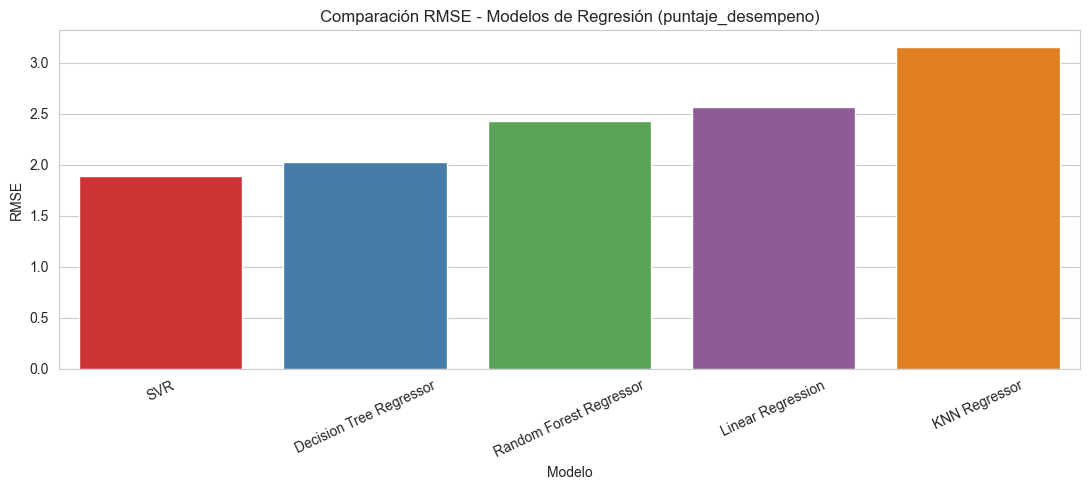

C:\Users\Arturo\AppData\Local\Temp\ipykernel_22140\3816113273.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


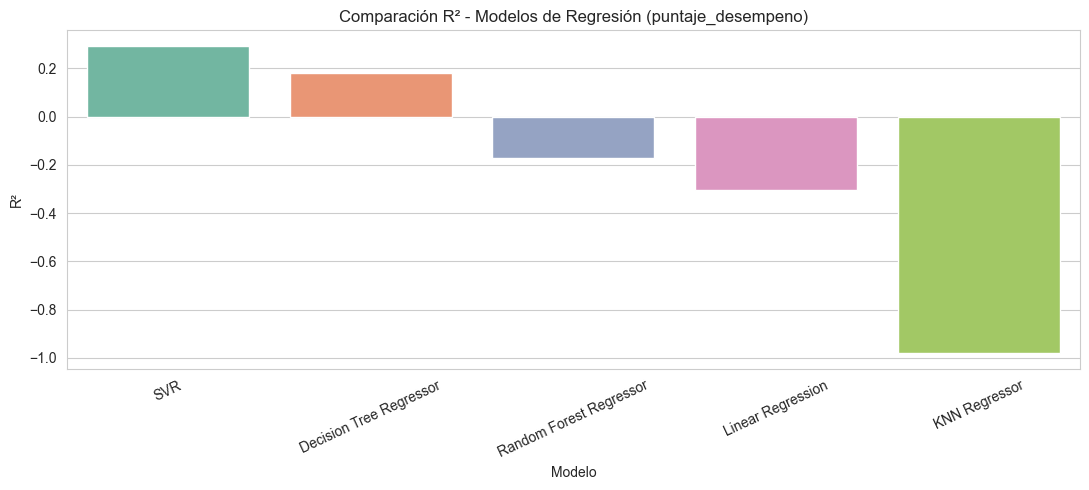

In [44]:
plt.figure(figsize=(11, 5))
sns.barplot(
    data=tabla_regresion.sort_values(by="rmse"),
    x="modelo",
    y="rmse",
    palette="Set1"
)
plt.title("Comparación RMSE - Modelos de Regresión (puntaje_desempeno)")
plt.xlabel("Modelo")
plt.ylabel("RMSE")
plt.xticks(rotation=25)
plt.tight_layout()
plt.savefig(os.path.join(project_root, 'results/plots/03_comparacion_regresion_rmse.png'), dpi=150, bbox_inches='tight')
plt.show()

plt.figure(figsize=(11, 5))
sns.barplot(
    data=tabla_regresion.sort_values(by="r2", ascending=False),
    x="modelo",
    y="r2",
    palette="Set2"
)
plt.title("Comparación R² - Modelos de Regresión (puntaje_desempeno)")
plt.xlabel("Modelo")
plt.ylabel("R²")
plt.xticks(rotation=25)
plt.tight_layout()
plt.savefig(os.path.join(project_root, 'results/plots/03_comparacion_regresion_r2.png'), dpi=150, bbox_inches='tight')
plt.show()


## Análisis de regresión

Se espera que Random Forest Regressor sea el mejor modelo en este problema.

Esto es coherente porque el puntaje de desempeño se relaciona con combinaciones no lineales entre competencias, ausencias y capacitaciones.

Modelos más simples como Linear Regression pueden capturar tendencias generales, pero no necesariamente representan bien interacciones complejas entre variables de RRHH.

SVR puede verse afectado por la escala y distribución del target si no se ajustan cuidadosamente sus hiperparámetros.


In [45]:
# Validación cruzada para compensar el dataset pequeño.
from sklearn.model_selection import cross_val_score

print("=== Validación Cruzada R² (CV=5) ===")
print("-" * 50)

for nombre, pipeline in pipelines_regresion.items():
    scores = cross_val_score(
        pipeline,
        X_reg,
        y_reg,
        cv=5,
        scoring="r2"
    )
    print(f"{nombre:<30}  Media: {scores.mean():.4f}  Std: ±{scores.std():.4f}")

=== Validación Cruzada R² (CV=5) ===
--------------------------------------------------
Linear Regression               Media: -0.1056  Std: ±0.1308
Decision Tree Regressor         Media: -2.2989  Std: ±2.6853
Random Forest Regressor         Media: -0.4198  Std: ±0.5152
KNN Regressor                   Media: -0.3817  Std: ±0.3865
SVR                             Media: 0.1894  Std: ±0.1993


In [46]:
from sklearn.model_selection import StratifiedKFold, KFold, cross_val_score

cv_clf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_reg = KFold(n_splits=5, shuffle=True, random_state=42)

print("=" * 55)
print("VALIDACIÓN CRUZADA — CLASIFICACIÓN (F1, CV=5)")
print("=" * 55)

for nombre, pipeline in pipelines_clasificacion.items():
    scores = cross_val_score(
        pipeline, X_clf, y_clf,
        cv=cv_clf, scoring='f1'
    )
    print(f"{nombre:<25}  {scores.mean():.4f}  ±{scores.std():.4f}")

print()
print("=" * 55)
print("VALIDACIÓN CRUZADA — REGRESIÓN (R², CV=5)")
print("=" * 55)

for nombre, pipeline in pipelines_regresion.items():
    scores = cross_val_score(
        pipeline, X_reg, y_reg,
        cv=cv_reg, scoring='r2'
    )
    print(f"{nombre:<25}  {scores.mean():.4f}  ±{scores.std():.4f}")

VALIDACIÓN CRUZADA — CLASIFICACIÓN (F1, CV=5)
Logistic Regression        0.7699  ±0.0348
Decision Tree              0.7451  ±0.0188
Random Forest              0.7453  ±0.0484
KNN                        0.6550  ±0.0359
SVM                        0.7537  ±0.0390
Gaussian NB                0.6190  ±0.0606
Gradient Boosting          0.7232  ±0.0415

VALIDACIÓN CRUZADA — REGRESIÓN (R², CV=5)
Linear Regression          -0.0180  ±0.1617
Decision Tree Regressor    -1.2792  ±2.2553
Random Forest Regressor    -0.0211  ±0.3729
KNN Regressor              -0.2880  ±0.3904
SVR                        0.1561  ±0.1652


# 18. Selección del mejor modelo de regresión

Se selecciona el modelo con menor RMSE y mayor R².


In [47]:
mejor_reg = tabla_regresion.sort_values(by="rmse", ascending=True).iloc[0]

mejor_modelo_reg_nombre = mejor_reg["modelo"]

print("Mejor modelo de regresión:", mejor_modelo_reg_nombre)

display(mejor_reg)


Mejor modelo de regresión: SVR


modelo         SVR
mae       1.159556
rmse      1.887047
r2        0.293766
Name: 4, dtype: object

## Interpretación de la selección

El mejor modelo de regresión será la base para la etapa de optimización.

Un buen modelo de regresión en el contexto de RRHH permite estimar el puntaje de desempeño de un empleado, lo cual puede usarse para ordenar y priorizar intervenciones de gestión de personas.


# 19. Gráfico real vs predicho del mejor regresor

Se visualiza la relación entre los valores reales y predichos del mejor modelo de regresión.

Un buen modelo de regresión debe mostrar los puntos cerca de la línea diagonal (predicción perfecta).


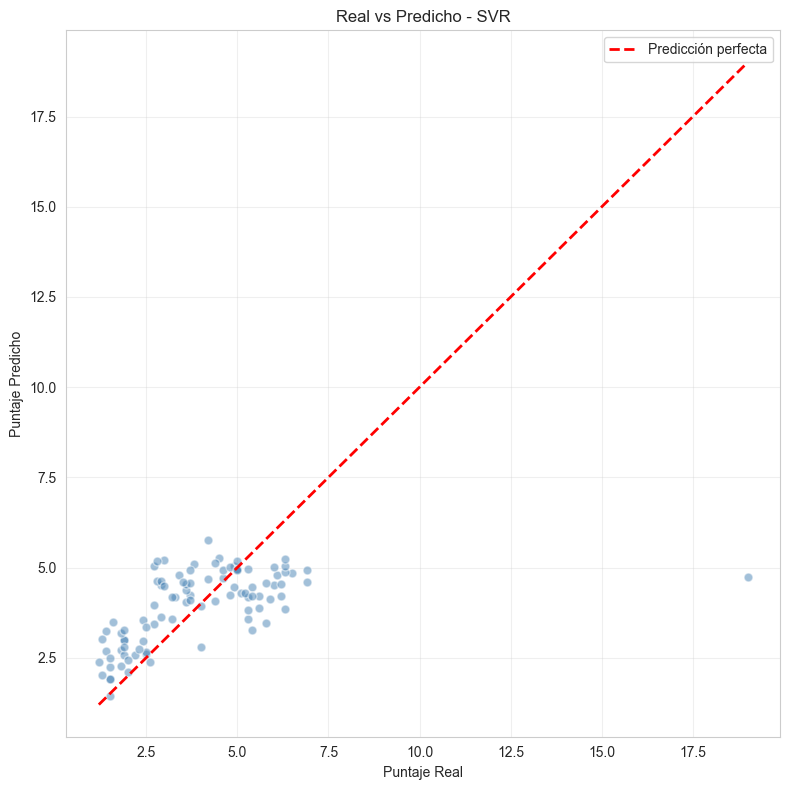

R² final: 0.2938
MAE final: 1.1596


In [48]:
y_pred_mejor = predicciones_regresion[mejor_modelo_reg_nombre]

plt.figure(figsize=(8, 8))
plt.scatter(y_test_reg, y_pred_mejor, alpha=0.5, color="steelblue", edgecolors="white", s=40)

lim = [min(y_test_reg.min(), y_pred_mejor.min()),
       max(y_test_reg.max(), y_pred_mejor.max())]
plt.plot(lim, lim, color="red", linestyle="--", lw=2, label="Predicción perfecta")

plt.xlabel("Puntaje Real")
plt.ylabel("Puntaje Predicho")
plt.title(f"Real vs Predicho - {mejor_modelo_reg_nombre}")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(project_root, 'results/plots/03_real_vs_predicho.png'), dpi=150, bbox_inches='tight')
plt.show()

mejor_pipeline_reg = pipelines_regresion[mejor_modelo_reg_nombre]
r2_final  = r2_score(y_test_reg, y_pred_mejor)
mae_final = mean_absolute_error(y_test_reg, y_pred_mejor)
print(f"R² final: {r2_final:.4f}")
print(f"MAE final: {mae_final:.4f}")


# 20. Importancia de variables - Regresión

Se analiza qué variables tienen mayor influencia en la estimación del puntaje de desempeño.


In [49]:
modelo_reg = mejor_pipeline_reg.named_steps["modelo"]

if hasattr(modelo_reg, "feature_importances_"):
    preprocesador_reg = mejor_pipeline_reg.named_steps["preprocesamiento"]

    try:
        nombres_num = preprocesador_reg.named_transformers_["num"]["imputer"].feature_names_in_.tolist()
        nombres_cat = preprocesador_reg.named_transformers_["cat"]["onehot"].get_feature_names_out().tolist()
        nombres_features = nombres_num + nombres_cat
    except Exception:
        nombres_features = [f"feature_{i}" for i in range(len(modelo_reg.feature_importances_))]

    importancias_reg = pd.Series(
        modelo_reg.feature_importances_,
        index=nombres_features
    ).sort_values(ascending=False).head(15)

    plt.figure(figsize=(11, 6))
    importancias_reg.plot(kind="barh", color="seagreen", edgecolor="black", alpha=0.85)
    plt.gca().invert_yaxis()
    plt.title(f"Top 15 Variables más Importantes - {mejor_modelo_reg_nombre} (Regresión)")
    plt.xlabel("Importancia")
    plt.grid(alpha=0.3, axis="x")
    plt.tight_layout()
    plt.savefig(os.path.join(project_root, 'results/plots/03_importancia_regresion.png'), dpi=150, bbox_inches='tight')
    plt.show()

elif hasattr(modelo_reg, "coef_"):
    print("El modelo usa coeficientes (regresión lineal).")
    coeficientes = pd.Series(
        np.abs(modelo_reg.coef_),
        index=[f"feature_{i}" for i in range(len(modelo_reg.coef_))]
    ).sort_values(ascending=False).head(15)

    plt.figure(figsize=(11, 6))
    coeficientes.plot(kind="barh", color="seagreen", edgecolor="black", alpha=0.85)
    plt.gca().invert_yaxis()
    plt.title(f"Top 15 Coeficientes - {mejor_modelo_reg_nombre}")
    plt.xlabel("|Coeficiente|")
    plt.grid(alpha=0.3, axis="x")
    plt.tight_layout()
    plt.show()

else:
    print(f"El modelo {mejor_modelo_reg_nombre} no expone importancias directamente.")


El modelo SVR no expone importancias directamente.


# 21. Conclusiones del notebook

Este notebook implementó y comparó modelos supervisados para predecir el desempeño de empleados.

Las principales conclusiones son:

1. Se definieron dos targets: `desempeno_alto` (clasificación) y `puntaje_desempeno` (regresión).
2. Se excluyeron variables con data leakage (`desempeno_bajo`, `riesgo_rotacion`) para asegurar modelos reproducibles.
3. Los modelos basados en árboles (Random Forest) suelen superar a modelos lineales en este tipo de datos, por las relaciones no lineales entre variables de RRHH.
4. Las variables de competencias técnicas y notas de capacitación se esperan como las más importantes.
5. La curva ROC y el AUC del mejor clasificador permiten evaluar su capacidad discriminante.
6. El gráfico real vs predicho del mejor regresor muestra visualmente la calidad del ajuste.

La siguiente etapa será optimizar los hiperparámetros del mejor modelo de cada tipo en `04_hyperparameter_optimization.ipynb`.
